Done by David Stekol and Jacob Khalili

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom, betabinom, norm,multivariate_normal
from scipy.special import expit

This is the gaussian generative model

In [2]:
# generate synthetic data
mean_1 = np.array([1, 1])
mean_2 = np.array([-1, -1])
sigma = np.eye(2)
N = 200
c1_n = 100
c1_p = c1_n / N
class1 = multivariate_normal(mean_1, sigma)
class1_samples  = class1.rvs(c1_n)
class1_test = class1.rvs(c1_n)
class1_mu = np.mean(class1_samples, axis=0)
class2 = multivariate_normal(mean_2, sigma)
class2_samples  = class2.rvs(N-c1_n)
class2_test = class2.rvs(N-c1_n)
class2_mu = np.mean(class2_samples, axis=0)
c2_p = 1 - c1_p
all_test = np.vstack((class1_test,class2_test))

In [3]:
# compute the weighted covariances
s_1 = np.cov(class1_samples, rowvar=False)
s_1 =  s_1 / c1_n
s_2 = np.cov(class2_samples, rowvar=False)
s_2 = s_2 / (N - c1_n)
s = s_1 * (c1_n/N) + s_2 * ((N - c1_n)/N)

In [4]:
# compute weights and bias
w = np.linalg.inv(s) @ (class1_mu - class2_mu)
w_0 = -0.5 * class1_mu.T @ np.linalg.inv(s) @ class1_mu + 0.5 * class2_mu.T @ np.linalg.inv(s) @ class2_mu + np.log(c1_p/c2_p)

In [5]:
# accuracy test
total_correct = 0
total_seen = 0
for sample in class1_test:
    val = w.T @ sample + w_0
    predicted = expit(val)
    if predicted >= 0.5:
        total_correct += 1
    total_seen += 1
for sample in class2_test:
    val = w.T @ sample + w_0
    predicted = 1-expit(val)
    if predicted > 0.5:
        total_correct += 1
    total_seen += 1
print(f"Percent classification is {100*total_correct/total_seen} % ")

Percent classification is 89.0 % 


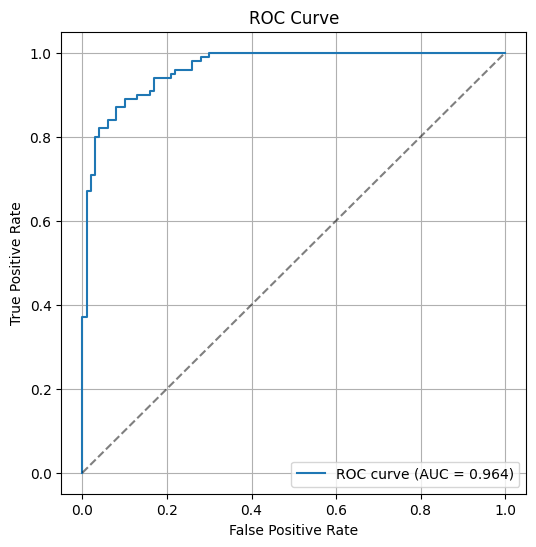

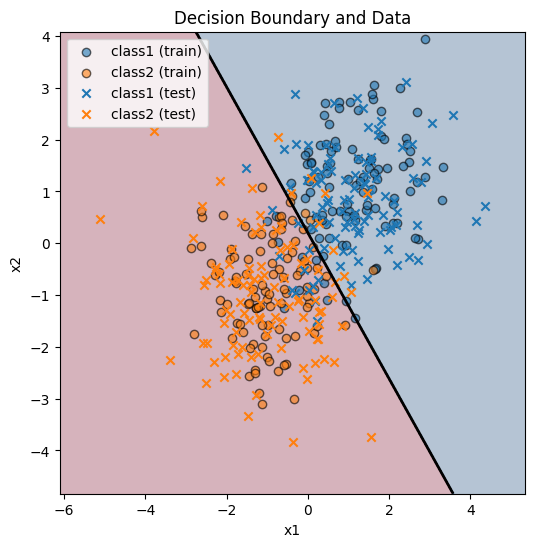

In [6]:
# Prepare test set and scores
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# X_test: N x 2, y_test: N (1 for class1, 0 for class2)
X_test = np.vstack((class1_test, class2_test))
y_test = np.hstack((np.ones(len(class1_test)), np.zeros(len(class2_test))))

# raw scores (decision function) and probabilities
scores = X_test @ w + w_0            # shape (N,)
probs = expit(scores)                # probabilities in (0,1)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, scores)  # use scores or probs
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot decision boundary over feature space
h = 0.02  # mesh step size
x_min, x_max = X_test[:,0].min() - 1, X_test[:,0].max() + 1
y_min, y_max = X_test[:,1].min() - 1, X_test[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_scores = grid @ w + w_0
Z = expit(Z_scores).reshape(xx.shape)

plt.figure(figsize=(6,6))
# contour at probability 0.5 -> decision boundary
cs = plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)

# scatter points
plt.scatter(class1_samples[:,0], class1_samples[:,1], c='tab:blue', edgecolor='k', label='class1 (train)', alpha=0.6)
plt.scatter(class2_samples[:,0], class2_samples[:,1], c='tab:orange', edgecolor='k', label='class2 (train)', alpha=0.6)
plt.scatter(class1_test[:,0], class1_test[:,1], c='tab:blue', marker='x', label='class1 (test)')
plt.scatter(class2_test[:,0], class2_test[:,1], c='tab:orange', marker='x', label='class2 (test)')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundary and Data')
plt.legend()
plt.show()

This is the logistic regression classifier

In [7]:
# initialize weights, generate design matrix
w_logit = np.array([0, 0])
design_matrix =  np.vstack((class1_samples, class2_samples))
labels = np.hstack((np.ones(c1_n), np.zeros(N - c1_n)))
num_epochs = 20
# had no clue how many times the iteration should be done and didn't feel like doing some optimization stuff, so 20 it is
for epoch in range(num_epochs):
    r_vector = np.array([])
    predicted_vector = np.array([])
    for i in range(N):
        xi = design_matrix[i]
        yi = labels[i]
        val = w_logit.T @ xi
        predicted = expit(val)
        predicted_vector = np.append(predicted_vector, predicted)
        r_vector  = np.append(r_vector, predicted*(1 - predicted))
    epsilon = 1e-8  # small value to regularize the diagonal
    R = np.diag(r_vector) + np.eye(N) * epsilon
    z = design_matrix @ w_logit - np.linalg.inv(R) @ (np.array(predicted_vector) - labels)
    w_logit = np.linalg.inv(design_matrix.T @ R @ design_matrix) @ (design_matrix.T @ R @ z)

In [8]:
# another accuracy test
total_correct = 0
total_seen = 0
for sample in class1_test:
    val = w_logit.T @ sample
    predicted = expit(val)
    if predicted >= 0.5:
        total_correct += 1
    total_seen += 1
for sample in class2_test:
    val = w_logit.T @ sample
    predicted = 1-expit(val)
    if predicted > 0.5:
        total_correct += 1
    total_seen += 1
print(f"Percent classification is {100*total_correct/total_seen} % ")

Percent classification is 88.5 % 


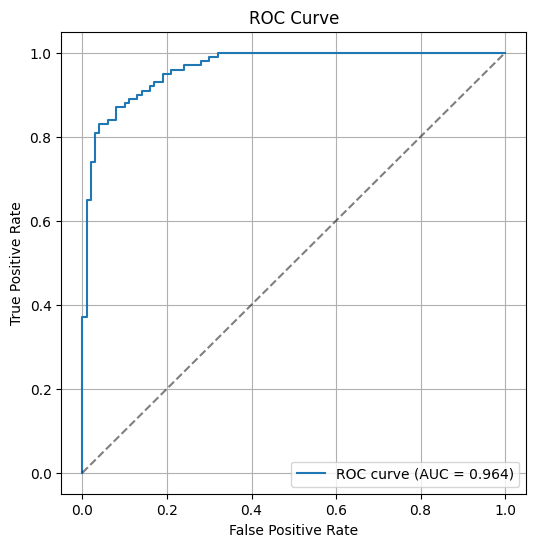

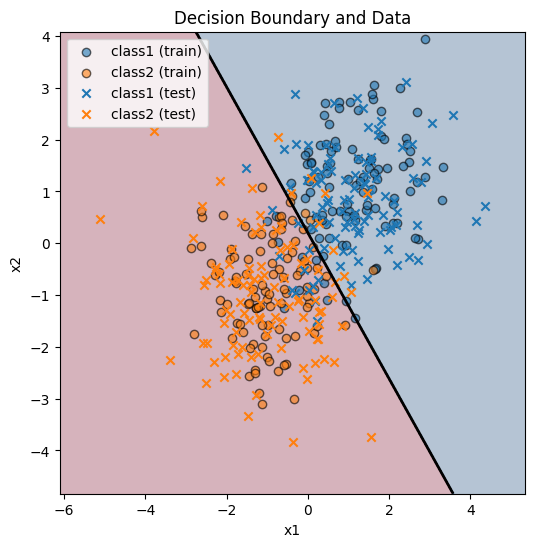

In [9]:
# Prepare test set and scores
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# X_test: N x 2, y_test: N (1 for class1, 0 for class2)
X_test = np.vstack((class1_test, class2_test))
y_test = np.hstack((np.ones(len(class1_test)), np.zeros(len(class2_test))))

# raw scores (decision function) and probabilities
scores = X_test @ w_logit           # shape (N,)
probs = expit(scores)                # probabilities in (0,1)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, scores)  # use scores or probs
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot decision boundary over feature space
h = 0.02  # mesh step size
x_min, x_max = X_test[:,0].min() - 1, X_test[:,0].max() + 1
y_min, y_max = X_test[:,1].min() - 1, X_test[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_scores = grid @ w + w_0
Z = expit(Z_scores).reshape(xx.shape)

plt.figure(figsize=(6,6))
# contour at probability 0.5 -> decision boundary
cs = plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)

# scatter points
plt.scatter(class1_samples[:,0], class1_samples[:,1], c='tab:blue', edgecolor='k', label='class1 (train)', alpha=0.6)
plt.scatter(class2_samples[:,0], class2_samples[:,1], c='tab:orange', edgecolor='k', label='class2 (train)', alpha=0.6)
plt.scatter(class1_test[:,0], class1_test[:,1], c='tab:blue', marker='x', label='class1 (test)')
plt.scatter(class2_test[:,0], class2_test[:,1], c='tab:orange', marker='x', label='class2 (test)')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundary and Data')
plt.legend()
plt.show()

The dataset we am testing on is the wisconsin breast cancer dataset from https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Breast Cancer test accuracy (IRLS w_logit): 91.81%
Breast Cancer AUC: 0.971


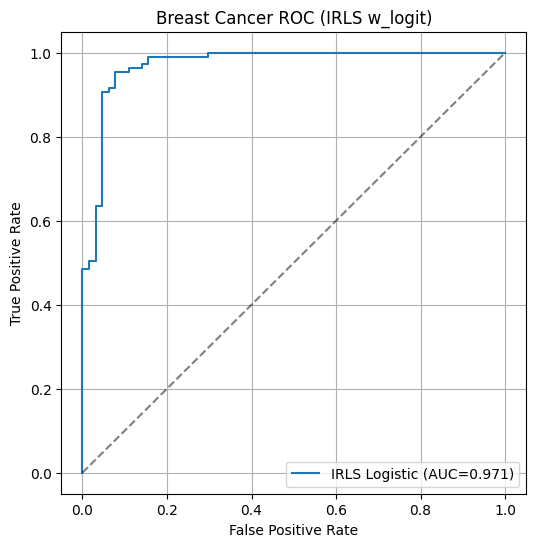

Breast Cancer test accuracy (Gaussian generative model): 93.57%
Breast Cancer AUC (GGM): 0.985


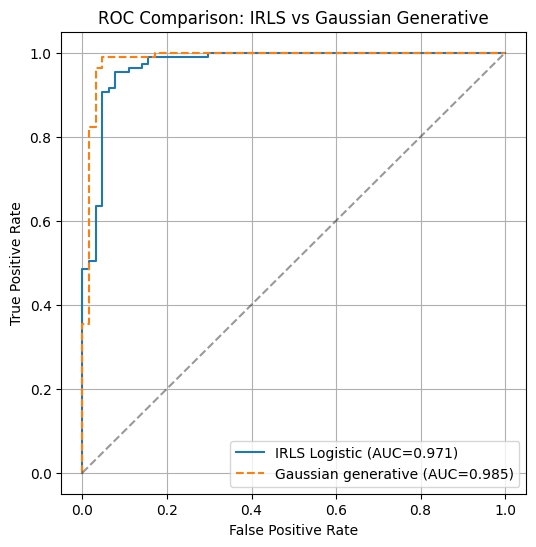

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score
from scipy.special import expit
import numpy as np
import matplotlib.pyplot as plt

# Load and prepare data
data = load_breast_cancer()
X = data.data.astype(float)  # numeric features
y = data.target.astype(int)  # 0/1 target

# Standardize features (helps IRLS converge more reliably)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Initialize weights
d = X_train.shape[1]
w_logit = np.zeros(d)

# IRLS parameters
num_epochs = 20
epsilon = 1e-8  # small regularizer for stability

# IRLS training loop
for epoch in range(num_epochs):
    # Predicted probabilities on training set
    p = expit(X_train @ w_logit)               # shape (N_train,)
    r = p * (1 - p)                            # diagonal entries
    # Regularize R and the X^T R X matrix to avoid singularities
    R = np.diag(r) + epsilon * np.eye(len(r))
    # Adjusted response z
    z = X_train @ w_logit - np.linalg.inv(R) @ (p - y_train)
    XtRX = X_train.T @ R @ X_train
    XtRz = X_train.T @ (R @ z)
    w_logit = np.linalg.inv(XtRX + epsilon * np.eye(d)) @ XtRz

# Inference on test set using learned w_logit
scores = X_test @ w_logit
probs = expit(scores)
preds = (probs >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, preds)
fpr, tpr, thresholds = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

print(f"Breast Cancer test accuracy (IRLS w_logit): {acc*100:.2f}%")
print(f"Breast Cancer AUC: {roc_auc:.3f}")

# Plot ROC curve for IRLS logistic
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'IRLS Logistic (AUC={roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Breast Cancer ROC (IRLS w_logit)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Now the gaussian
X1 = X_train[y_train == 1]
X0 = X_train[y_train == 0]
mu1 = X1.mean(axis=0)
mu0 = X0.mean(axis=0)
n1 = X1.shape[0]
n0 = X0.shape[0]
pi1 = n1 / (n1 + n0)
pi0 = n0 / (n1 + n0)
# unbiased sample covariance
S1 = np.cov(X1, rowvar=False)
S0 = np.cov(X0, rowvar=False)
# pooled covariance (use unbiased estimator)
S_pooled = ((n1 - 1) * S1 + (n0 - 1) * S0) / (n1 + n0 - 2)
# regularize for numeric stability
eps_cov = 1e-6
invS = np.linalg.inv(S_pooled + eps_cov * np.eye(S_pooled.shape[0]))
# compute weights
w_ggm = invS @ (mu1 - mu0)
w0_ggm = -0.5 * mu1.T @ invS @ mu1 + 0.5 * mu0.T @ invS @ mu0 + np.log(pi1 / pi0)
# evaluate on test set
scores_ggm = X_test @ w_ggm + w0_ggm
probs_ggm = expit(scores_ggm)
preds_ggm = (probs_ggm >= 0.5).astype(int)
acc_ggm = accuracy_score(y_test, preds_ggm)
fpr_g, tpr_g, th_g = roc_curve(y_test, scores_ggm)
roc_auc_g = auc(fpr_g, tpr_g)

print(f"Breast Cancer test accuracy (Gaussian generative model): {acc_ggm*100:.2f}%")
print(f"Breast Cancer AUC (GGM): {roc_auc_g:.3f}")

# Plot both ROC curves for comparison
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'IRLS Logistic (AUC={roc_auc:.3f})')
plt.plot(fpr_g, tpr_g, label=f'Gaussian generative (AUC={roc_auc_g:.3f})', linestyle='--')
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison: IRLS vs Gaussian Generative')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()